# Oil Price Forecasting: ARIMA vs LSTM

This notebook is a complete, submission-ready coding file for the oil price assignment. It covers:

- data loading and exploratory analysis
- stationarity testing and differencing checks
- exhaustive `p,d,q` search for the ARIMA/ARMA-family model using AIC
- residual diagnostics and hold-out evaluation
- a nonlinear alternative model using LSTM
- 24-month future forecasts with confidence intervals
- final model comparison tables and plots

**Dataset:** `oil_prices_2426.csv`  
**Assumption for the 24-month forecast:** the series is daily, so forecasts are produced for every day from the last observed date to the same calendar date 24 months later.

## Notebook structure

1. Setup and data preparation  
2. EDA and stationarity analysis  
3. ARIMA model search, diagnostics, and 24-month forecast  
4. LSTM model tuning, evaluation, and 24-month forecast  
5. Final comparison

In [1]:
import contextlib
import io
import math
import os
import random
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning

CACHE_DIR = Path(".cache")
MPL_DIR = CACHE_DIR / "matplotlib"
XDG_DIR = CACHE_DIR / "xdg"
MPL_DIR.mkdir(parents=True, exist_ok=True)
XDG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_DIR.resolve())
os.environ["XDG_CACHE_HOME"] = str(XDG_DIR.resolve())
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


@contextlib.contextmanager
def suppress_fd_output():
    stdout_fd = sys.stdout.fileno()
    stderr_fd = sys.stderr.fileno()
    old_stdout = os.dup(stdout_fd)
    old_stderr = os.dup(stderr_fd)
    with open(os.devnull, "w") as devnull:
        os.dup2(devnull.fileno(), stdout_fd)
        os.dup2(devnull.fileno(), stderr_fd)
        try:
            yield
        finally:
            os.dup2(old_stdout, stdout_fd)
            os.dup2(old_stderr, stderr_fd)
            os.close(old_stdout)
            os.close(old_stderr)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def metric_frame(y_true, y_pred, model_name):
    return pd.DataFrame(
        [
            {
                "model": model_name,
                "RMSE": rmse(y_true, y_pred),
                "MAE": mean_absolute_error(y_true, y_pred),
                "MAPE (%)": mape(y_true, y_pred),
            }
        ]
    )


def adf_test(series):
    result = adfuller(series.dropna(), autolag="AIC")
    return {"statistic": result[0], "p_value": result[1], "lags": result[2]}


def kpss_test(series):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    return {"statistic": result[0], "p_value": result[1], "lags": result[2]}


def stationarity_summary(series):
    variants = {
        "Original": series,
        "1st difference": series.diff().dropna(),
        "2nd difference": series.diff().diff().dropna(),
    }
    rows = []
    for name, sample in variants.items():
        adf_res = adf_test(sample)
        kpss_res = kpss_test(sample)
        rows.append(
            {
                "Series": name,
                "ADF statistic": adf_res["statistic"],
                "ADF p-value": adf_res["p_value"],
                "KPSS statistic": kpss_res["statistic"],
                "KPSS p-value": kpss_res["p_value"],
            }
        )
    return pd.DataFrame(rows)


def make_sequences(values, look_back):
    X, y = [], []
    for idx in range(look_back, len(values)):
        X.append(values[idx - look_back : idx, 0])
        y.append(values[idx, 0])
    X = np.array(X).reshape(-1, look_back, 1)
    y = np.array(y)
    return X, y


def future_daily_index(last_date, months_ahead=24):
    forecast_end = last_date + pd.DateOffset(months=months_ahead)
    return pd.date_range(last_date + pd.Timedelta(days=1), forecast_end, freq="D")


DATA_PATH = Path("oil_prices_2426.csv")

In [2]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date")
series = df.set_index("date")["price (dollars)"].asfreq("D")

profile = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Start date",
            "End date",
            "Missing values",
            "Mean price",
            "Median price",
            "Minimum price",
            "Maximum price",
            "Standard deviation",
        ],
        "Value": [
            len(series),
            series.index.min().date(),
            series.index.max().date(),
            int(series.isna().sum()),
            round(series.mean(), 3),
            round(series.median(), 3),
            round(series.min(), 3),
            round(series.max(), 3),
            round(series.std(), 3),
        ],
    }
)

display(profile)
display(df.head())

,Metric,Value
0,Rows,500
1,Start date,2024-09-21
2,End date,2026-02-02
3,Missing values,0
4,Mean price,75.874
5,Median price,64.29
6,Minimum price,16.48
7,Maximum price,158.78
8,Standard deviation,42.912


,date,price (dollars)
0,2024-09-21,32.10
1,2024-09-22,32.25
2,2024-09-23,31.07
3,2024-09-24,31.50
4,2024-09-25,32.21


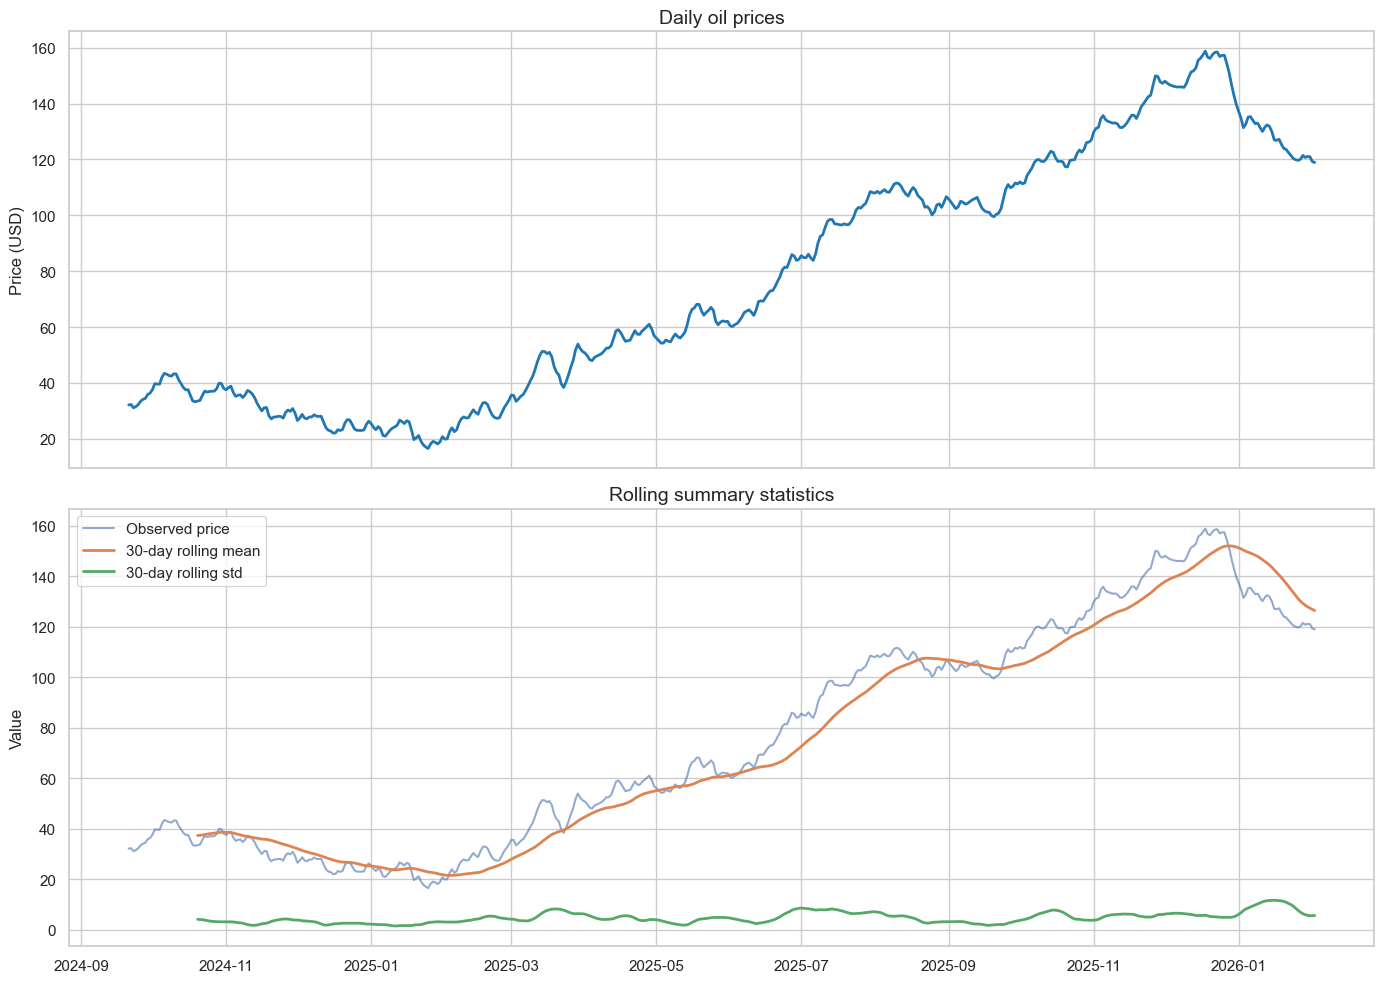

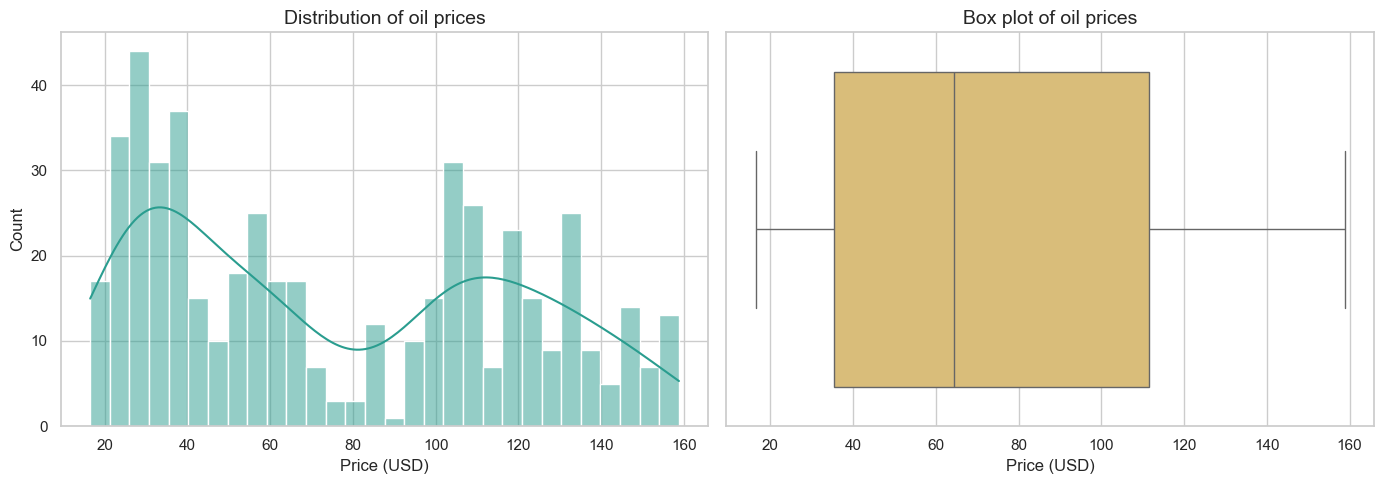

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(series.index, series.values, color="#1f77b4", linewidth=2)
axes[0].set_title("Daily oil prices")
axes[0].set_ylabel("Price (USD)")

rolling_mean = series.rolling(window=30).mean()
rolling_std = series.rolling(window=30).std()
axes[1].plot(series.index, series.values, label="Observed price", alpha=0.6)
axes[1].plot(rolling_mean.index, rolling_mean.values, label="30-day rolling mean", linewidth=2)
axes[1].plot(rolling_std.index, rolling_std.values, label="30-day rolling std", linewidth=2)
axes[1].set_title("Rolling summary statistics")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(series, bins=30, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribution of oil prices")
axes[0].set_xlabel("Price (USD)")

sns.boxplot(x=series.values, ax=axes[1], color="#e9c46a")
axes[1].set_title("Box plot of oil prices")
axes[1].set_xlabel("Price (USD)")

plt.tight_layout()
plt.show()

## Stationarity analysis

The assignment requires explicit testing for non-stationarity before fitting the ARIMA/ARMA-family model.  
The notebook therefore checks:

- ADF: null hypothesis = non-stationary series  
- KPSS: null hypothesis = stationary series  
- ACF/PACF behaviour before and after differencing

,Series,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,Original,-0.5462,0.8827,3.7056,0.01
1,1st difference,-4.5415,0.0002,0.1903,0.10
2,2nd difference,-9.0042,0.0000,0.1290,0.10


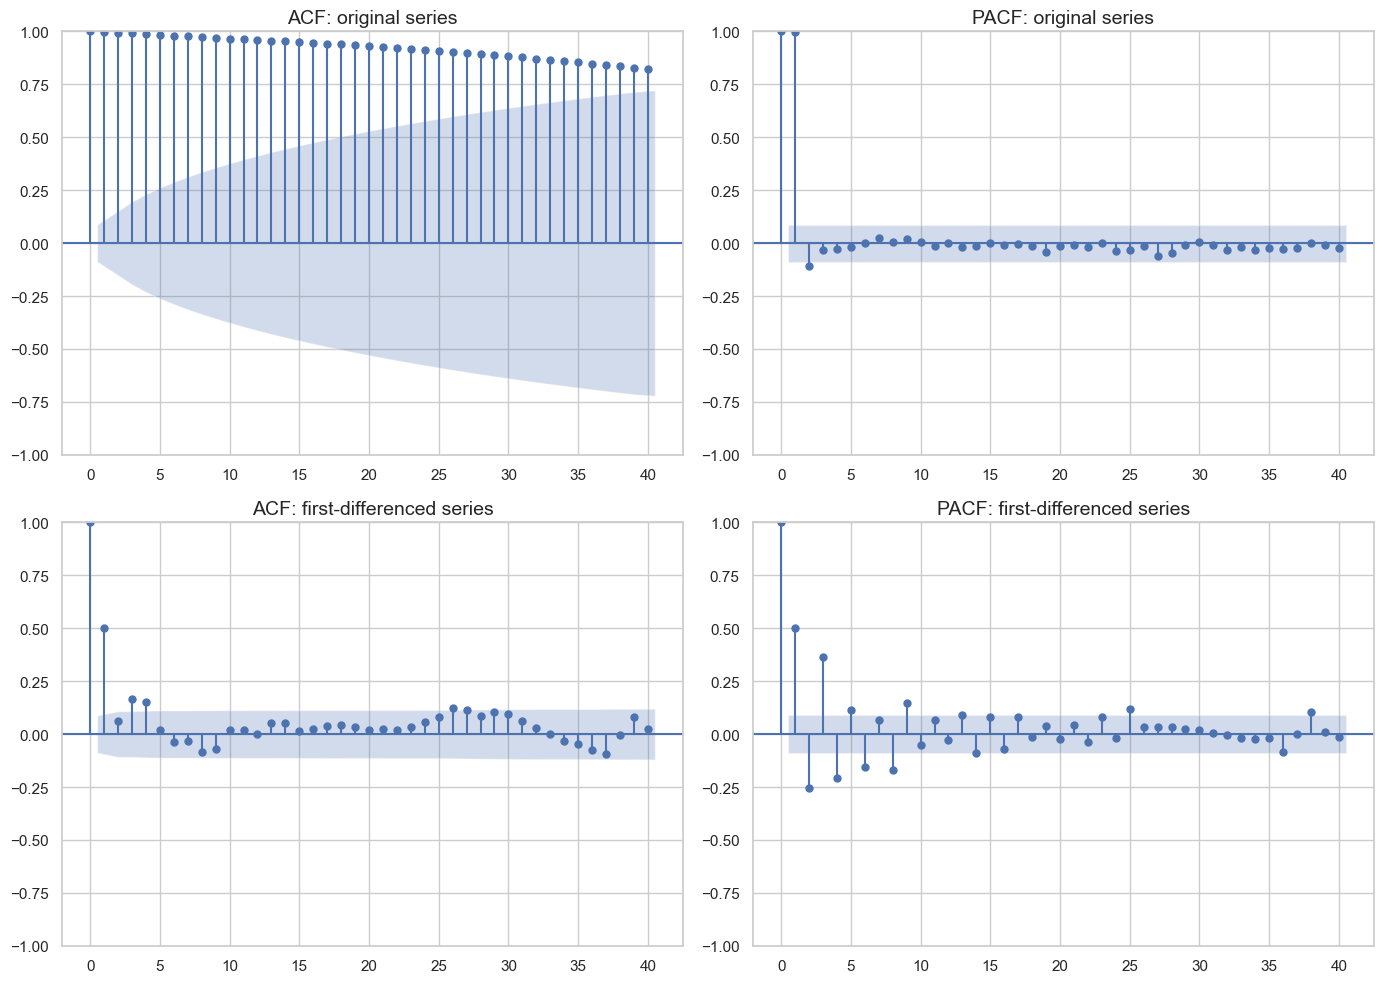

In [4]:
stationarity_table = stationarity_summary(series).round(4)
display(stationarity_table)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_acf(series.dropna(), ax=axes[0, 0], lags=40)
axes[0, 0].set_title("ACF: original series")
plot_pacf(series.dropna(), ax=axes[0, 1], lags=40, method="ywm")
axes[0, 1].set_title("PACF: original series")

diff_1 = series.diff().dropna()
plot_acf(diff_1, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("ACF: first-differenced series")
plot_pacf(diff_1, ax=axes[1, 1], lags=40, method="ywm")
axes[1, 1].set_title("PACF: first-differenced series")

plt.tight_layout()
plt.show()

In [5]:
TEST_SIZE = 90
VAL_SIZE = 45

arima_train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

lstm_train = series.iloc[: -(TEST_SIZE + VAL_SIZE)]
lstm_val = series.iloc[-(TEST_SIZE + VAL_SIZE) : -TEST_SIZE]
lstm_train_full = series.iloc[:-TEST_SIZE]

split_summary = pd.DataFrame(
    [
        {"Split": "ARIMA training window", "Observations": len(arima_train)},
        {"Split": "LSTM training window", "Observations": len(lstm_train)},
        {"Split": "LSTM validation window", "Observations": len(lstm_val)},
        {"Split": "Common test window", "Observations": len(test)},
    ]
)
display(split_summary)

,Split,Observations
0,ARIMA training window,410
1,LSTM training window,365
2,LSTM validation window,45
3,Common test window,90


## Part 1: ARIMA/ARMA-family modelling

The brief asks for a loop over all parameter combinations:

- `p = 0..8`
- `d = 0..2`
- `q = 0..8`

The code below performs the required exhaustive search and ranks models by AIC.

In [6]:
def grid_search_arima(series, p_values=range(9), d_values=range(3), q_values=range(9), maxiter=20):
    records = []
    start_time = time.time()
    total_models = len(p_values) * len(d_values) * len(q_values)

    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        fit = ARIMA(
                            series,
                            order=order,
                            enforce_stationarity=False,
                            enforce_invertibility=False,
                        ).fit(method_kwargs={"maxiter": maxiter})
                    if np.isfinite(fit.aic):
                        records.append(
                            {
                                "order": order,
                                "p": p,
                                "d": d,
                                "q": q,
                                "AIC": fit.aic,
                            }
                        )
                except Exception:
                    continue

    results = pd.DataFrame(records).sort_values("AIC").reset_index(drop=True)
    elapsed = time.time() - start_time
    print(f"Evaluated {len(results)} valid models out of {total_models} combinations in {elapsed:.2f} seconds.")
    return results


arima_search_results = grid_search_arima(arima_train)
display(arima_search_results.head(10).round(4))

best_arima_order = tuple(arima_search_results.iloc[0]["order"])
print(f"Best ARIMA order by AIC: {best_arima_order}")

Evaluated 243 valid models out of 243 combinations in 32.19 seconds.


,order,p,d,q,AIC
0,"(0, 2, 8)",0,2,8,1136.2820
1,"(8, 2, 2)",8,2,2,1137.6081
2,"(0, 2, 7)",0,2,7,1137.7121
3,"(1, 2, 8)",1,2,8,1138.2767
4,"(8, 2, 3)",8,2,3,1139.4500
5,"(0, 2, 6)",0,2,6,1139.5806
6,"(1, 2, 7)",1,2,7,1139.8524
7,"(2, 2, 8)",2,2,8,1140.6432
8,"(2, 2, 7)",2,2,7,1140.7095
9,"(6, 2, 8)",6,2,8,1140.8439


Best ARIMA order by AIC: (0, 2, 8)


,model,RMSE,MAE,MAPE (%)
0,ARIMA,26.1477,17.8984,14.0247


,Actual,ARIMA prediction,ARIMA lower 95%,ARIMA upper 95%
2025-11-05,135.73,137.002,135.085,138.919
2025-11-06,134.27,137.216,132.985,141.446
2025-11-07,133.65,137.594,131.978,143.209
2025-11-08,133.36,138.345,131.571,145.119
2025-11-09,133.01,138.808,130.858,146.759


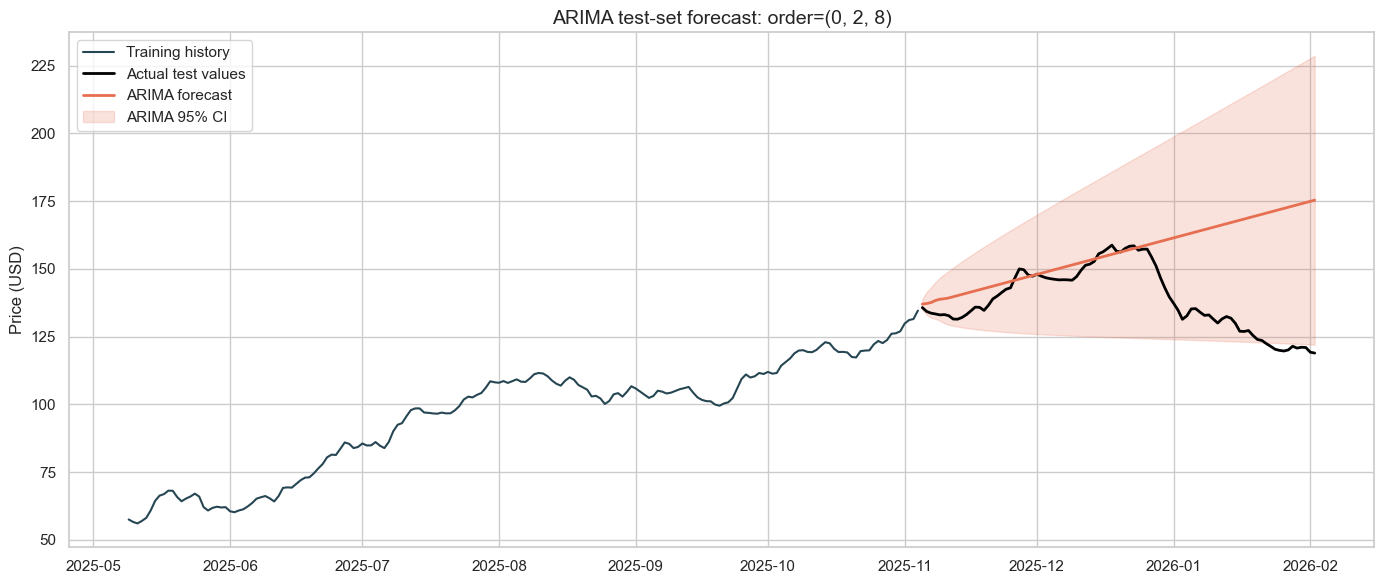

In [7]:
best_arima = ARIMA(
    arima_train,
    order=best_arima_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(method_kwargs={"maxiter": 100})

arima_test_forecast = best_arima.get_forecast(steps=len(test))
arima_test_mean = arima_test_forecast.predicted_mean
arima_test_ci = arima_test_forecast.conf_int(alpha=0.05)

arima_metrics = metric_frame(test, arima_test_mean, "ARIMA")
display(arima_metrics.round(4))

comparison_df = pd.DataFrame(
    {
        "Actual": test,
        "ARIMA prediction": arima_test_mean,
        "ARIMA lower 95%": arima_test_ci.iloc[:, 0],
        "ARIMA upper 95%": arima_test_ci.iloc[:, 1],
    }
)
display(comparison_df.head().round(3))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(arima_train.index[-180:], arima_train.iloc[-180:], label="Training history", color="#264653")
ax.plot(test.index, test.values, label="Actual test values", color="#000000", linewidth=2)
ax.plot(test.index, arima_test_mean.values, label="ARIMA forecast", color="#e76f51", linewidth=2)
ax.fill_between(
    test.index,
    arima_test_ci.iloc[:, 0].values,
    arima_test_ci.iloc[:, 1].values,
    color="#e76f51",
    alpha=0.2,
    label="ARIMA 95% CI",
)
ax.set_title(f"ARIMA test-set forecast: order={best_arima_order}")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

Ljung-Box test on ARIMA residuals


,lb_stat,lb_pvalue
10,52.5131,0.0
20,54.6622,0.0


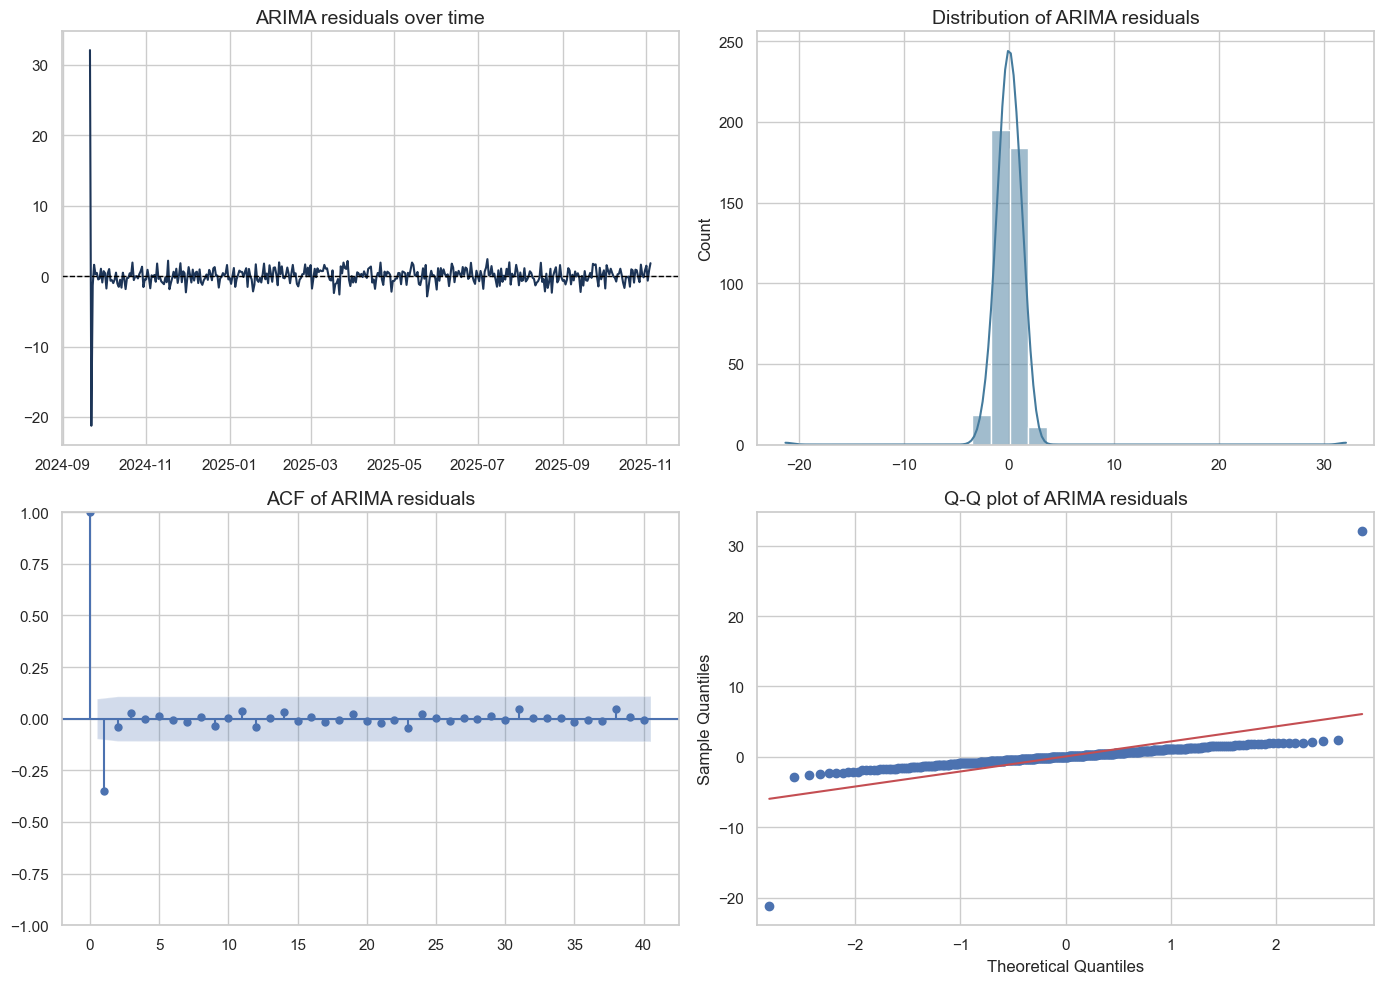

In [8]:
arima_residuals = pd.Series(best_arima.resid, index=arima_train.index).dropna()
ljung_box = acorr_ljungbox(arima_residuals, lags=[10, 20], return_df=True)

print("Ljung-Box test on ARIMA residuals")
display(ljung_box.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(arima_residuals.index, arima_residuals.values, color="#1d3557")
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("ARIMA residuals over time")

sns.histplot(arima_residuals, bins=30, kde=True, ax=axes[0, 1], color="#457b9d")
axes[0, 1].set_title("Distribution of ARIMA residuals")

plot_acf(arima_residuals, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("ACF of ARIMA residuals")

qqplot(arima_residuals, line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q plot of ARIMA residuals")

plt.tight_layout()
plt.show()

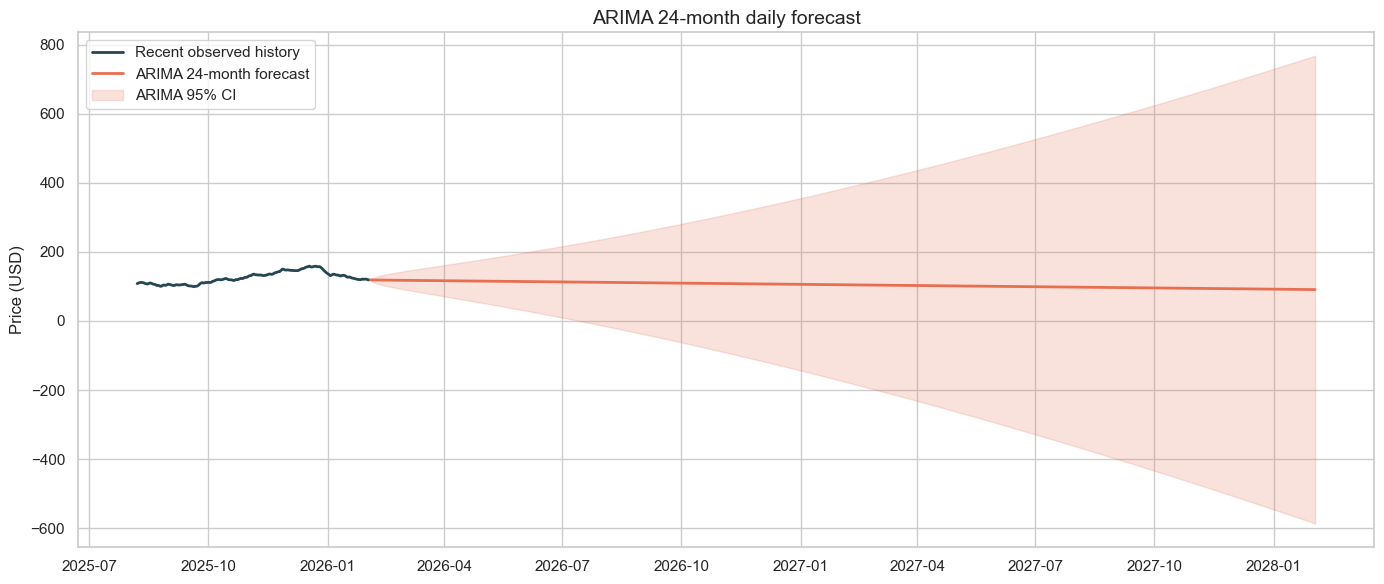

,ARIMA forecast,lower,upper
2026-02-03,119.065,117.099,121.031
2026-02-04,118.811,114.465,123.157
2026-02-05,118.535,112.706,124.365
2026-02-06,118.479,111.336,125.623
2026-02-07,118.554,110.048,127.061


In [9]:
full_arima = ARIMA(
    series,
    order=best_arima_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(method_kwargs={"maxiter": 100})

future_index = future_daily_index(series.index.max(), months_ahead=24)
arima_future = full_arima.get_forecast(steps=len(future_index))
arima_future_mean = pd.Series(arima_future.predicted_mean.values, index=future_index, name="ARIMA forecast")
arima_future_ci = pd.DataFrame(
    arima_future.conf_int(alpha=0.05).values,
    index=future_index,
    columns=["lower", "upper"],
)

fig, ax = plt.subplots(figsize=(14, 6))
history_window = series.iloc[-180:]
ax.plot(history_window.index, history_window.values, label="Recent observed history", color="#264653", linewidth=2)
ax.plot(arima_future_mean.index, arima_future_mean.values, label="ARIMA 24-month forecast", color="#e76f51", linewidth=2)
ax.fill_between(
    arima_future_ci.index,
    arima_future_ci["lower"].values,
    arima_future_ci["upper"].values,
    color="#e76f51",
    alpha=0.2,
    label="ARIMA 95% CI",
)
ax.set_title("ARIMA 24-month daily forecast")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

display(pd.concat([arima_future_mean.head(5), arima_future_ci.head(5)], axis=1).round(3))

## Part 2: Alternative model using LSTM

A recurrent neural network is a defensible alternative because the oil-price series shows strong trend changes and possible nonlinear behaviour.  
The model below uses:

- min-max scaling
- sliding windows of past observations
- hyperparameter search over look-back window and hidden units
- early stopping to reduce overfitting
- recursive 24-month forecasting

For the LSTM confidence interval, the notebook uses an approximate residual-based interval:

- first compute out-of-sample residual spread on the test window
- then expand the interval with `sqrt(h)` as forecast uncertainty grows with horizon

In [10]:
with suppress_fd_output():
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Dense, Dropout, Input, LSTM

tf.keras.utils.set_random_seed(SEED)


def build_lstm_model(look_back, units):
    model = Sequential(
        [
            Input(shape=(look_back, 1)),
            LSTM(units, activation="tanh"),
            Dropout(0.2),
            Dense(max(16, units // 2), activation="relu"),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse")
    return model


def fit_keras_silently(model, *args, **kwargs):
    with suppress_fd_output():
        history = model.fit(*args, **kwargs)
    return history


def predict_keras_silently(model, *args, **kwargs):
    with suppress_fd_output():
        preds = model.predict(*args, **kwargs)
    return preds


def tune_lstm_model(train_series, val_series, look_backs=(14, 30, 45), unit_options=(32, 64)):
    train_values = train_series.values.reshape(-1, 1)
    val_values = val_series.values.reshape(-1, 1)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_values)
    val_scaled = scaler.transform(val_values)

    results = []
    best_config = None

    for look_back in look_backs:
        X_train, y_train = make_sequences(train_scaled, look_back)
        X_val, y_val = make_sequences(np.vstack([train_scaled[-look_back:], val_scaled]), look_back)

        for units in unit_options:
            tf.keras.backend.clear_session()
            model = build_lstm_model(look_back, units)
            stopper = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
            history = fit_keras_silently(
                model,
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=120,
                batch_size=16,
                verbose=0,
                callbacks=[stopper],
            )
            best_val = min(history.history["val_loss"])
            row = {
                "look_back": look_back,
                "units": units,
                "best_val_loss": best_val,
                "epochs_ran": len(history.history["loss"]),
            }
            results.append(row)
            if best_config is None or best_val < best_config["best_val_loss"]:
                best_config = row

    results_df = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)
    return results_df, best_config


lstm_tuning_results, best_lstm_config = tune_lstm_model(lstm_train, lstm_val)
display(lstm_tuning_results.round(6))
print(f"Selected LSTM configuration: {best_lstm_config}")

,look_back,units,best_val_loss,epochs_ran
0,30,64,0.001337,16
1,14,64,0.001453,14
2,30,32,0.001790,13
3,45,32,0.002492,17
4,45,64,0.002862,23
5,14,32,0.003594,36


Selected LSTM configuration: {'look_back': 30, 'units': 64, 'best_val_loss': 0.001336598419584334, 'epochs_ran': 16}


,model,RMSE,MAE,MAPE (%)
0,LSTM,4.1729,3.0175,2.1803


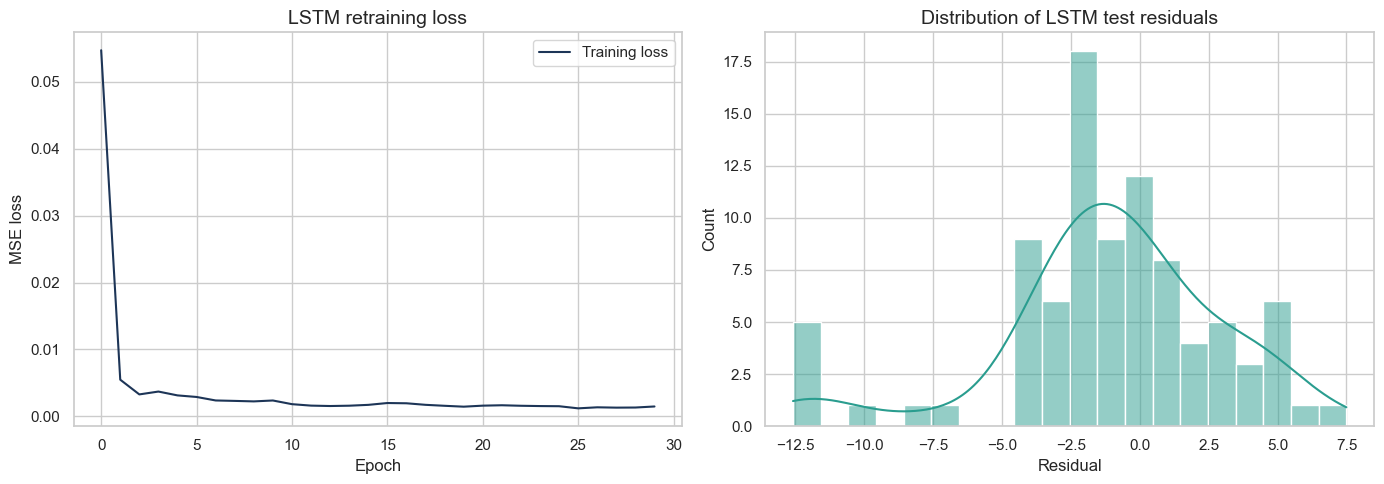

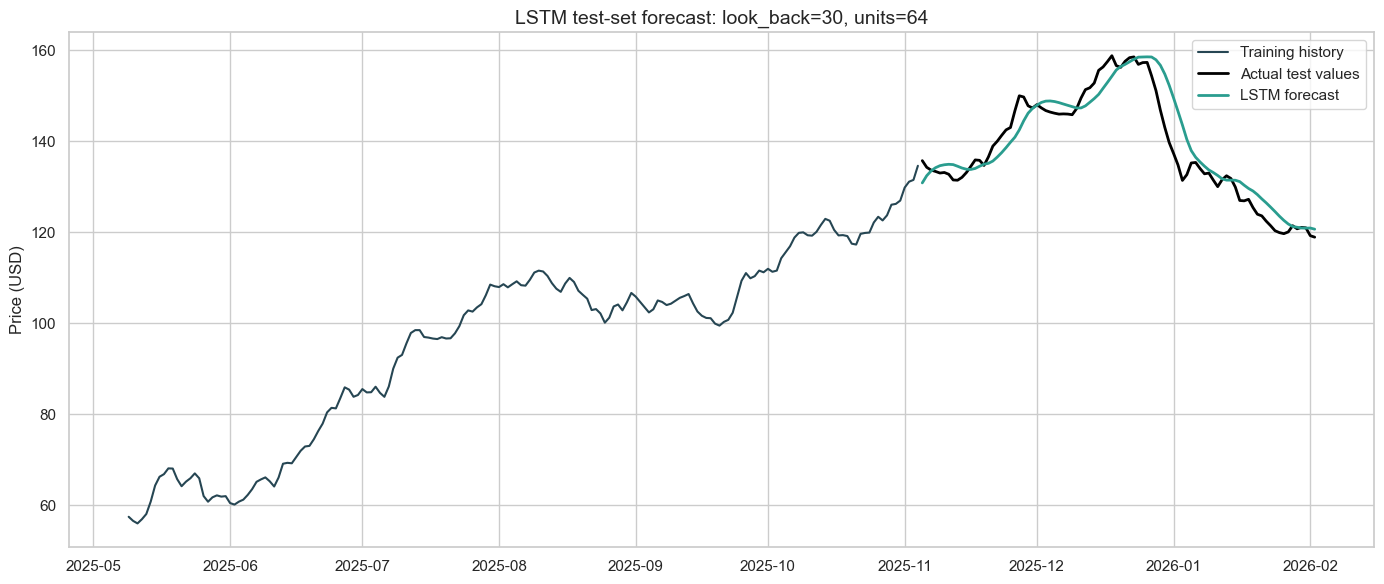

In [11]:
look_back = int(best_lstm_config["look_back"])
units = int(best_lstm_config["units"])
retrain_epochs = max(30, int(best_lstm_config["epochs_ran"]))

scaler = MinMaxScaler()
train_full_values = lstm_train_full.values.reshape(-1, 1)
test_values = test.values.reshape(-1, 1)

train_full_scaled = scaler.fit_transform(train_full_values)
test_scaled = scaler.transform(test_values)
X_train_full, y_train_full = make_sequences(train_full_scaled, look_back)

tf.keras.backend.clear_session()
lstm_model = build_lstm_model(look_back, units)
stopper = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
lstm_history = fit_keras_silently(
    lstm_model,
    X_train_full,
    y_train_full,
    epochs=retrain_epochs,
    batch_size=16,
    verbose=0,
    callbacks=[stopper],
)

combined_scaled = np.vstack([train_full_scaled, test_scaled])
lstm_test_preds_scaled = []
for step in range(len(test_scaled)):
    start = len(train_full_scaled) + step - look_back
    window = combined_scaled[start : start + look_back].reshape(1, look_back, 1)
    pred = predict_keras_silently(lstm_model, window, verbose=0)[0, 0]
    lstm_test_preds_scaled.append(pred)

lstm_test_preds = scaler.inverse_transform(np.array(lstm_test_preds_scaled).reshape(-1, 1)).ravel()
lstm_metrics = metric_frame(test.values, lstm_test_preds, "LSTM")
display(lstm_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lstm_history.history["loss"], label="Training loss", color="#1d3557")
axes[0].set_title("LSTM retraining loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

lstm_test_residuals = test.values - lstm_test_preds
sns.histplot(lstm_test_residuals, bins=20, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Distribution of LSTM test residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(lstm_train_full.index[-180:], lstm_train_full.iloc[-180:], label="Training history", color="#264653")
ax.plot(test.index, test.values, label="Actual test values", color="#000000", linewidth=2)
ax.plot(test.index, lstm_test_preds, label="LSTM forecast", color="#2a9d8f", linewidth=2)
ax.set_title(f"LSTM test-set forecast: look_back={look_back}, units={units}")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

,LSTM forecast,lower,upper
2026-02-03,122.250999,114.317,130.186
2026-02-04,122.757004,111.536,133.978
2026-02-05,123.333000,109.590,137.076
2026-02-06,123.962997,108.094,139.832
2026-02-07,124.634003,106.892,142.376


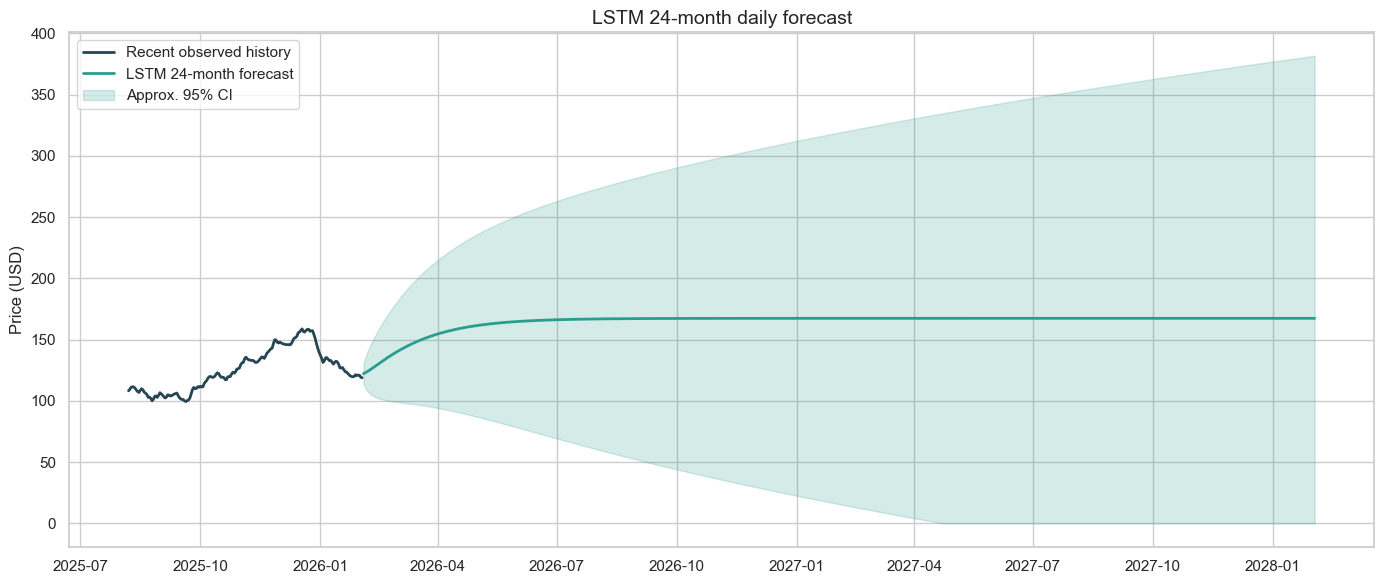

In [12]:
full_scaler = MinMaxScaler()
full_values = series.values.reshape(-1, 1)
full_scaled = full_scaler.fit_transform(full_values)
X_full, y_full = make_sequences(full_scaled, look_back)

tf.keras.backend.clear_session()
full_lstm_model = build_lstm_model(look_back, units)
final_stopper = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
_ = fit_keras_silently(
    full_lstm_model,
    X_full,
    y_full,
    epochs=retrain_epochs,
    batch_size=16,
    verbose=0,
    callbacks=[final_stopper],
)

future_scaled_preds = []
rolling_window = full_scaled[-look_back:].copy()
for _ in range(len(future_index)):
    pred_scaled = predict_keras_silently(
        full_lstm_model,
        rolling_window.reshape(1, look_back, 1),
        verbose=0,
    )[0, 0]
    future_scaled_preds.append(pred_scaled)
    rolling_window = np.vstack([rolling_window[1:], [[pred_scaled]]])

lstm_future_mean = full_scaler.inverse_transform(np.array(future_scaled_preds).reshape(-1, 1)).ravel()
residual_sigma = np.std(lstm_test_residuals, ddof=1)
horizon = np.arange(1, len(future_index) + 1)
interval_half_width = 1.96 * residual_sigma * np.sqrt(horizon)

lstm_future_lower = np.clip(lstm_future_mean - interval_half_width, a_min=0, a_max=None)
lstm_future_upper = lstm_future_mean + interval_half_width

lstm_future_df = pd.DataFrame(
    {
        "LSTM forecast": lstm_future_mean,
        "lower": lstm_future_lower,
        "upper": lstm_future_upper,
    },
    index=future_index,
)
display(lstm_future_df.head().round(3))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(series.index[-180:], series.iloc[-180:], label="Recent observed history", color="#264653", linewidth=2)
ax.plot(future_index, lstm_future_mean, label="LSTM 24-month forecast", color="#2a9d8f", linewidth=2)
ax.fill_between(
    future_index,
    lstm_future_lower,
    lstm_future_upper,
    color="#2a9d8f",
    alpha=0.2,
    label="Approx. 95% CI",
)
ax.set_title("LSTM 24-month daily forecast")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Final comparison

The table and plots below summarise which model is stronger on the held-out test window and how their 24-month forecasts differ.

,model,RMSE,MAE,MAPE (%)
1,LSTM,4.1729,3.0175,2.1803
0,ARIMA,26.1477,17.8984,14.0247


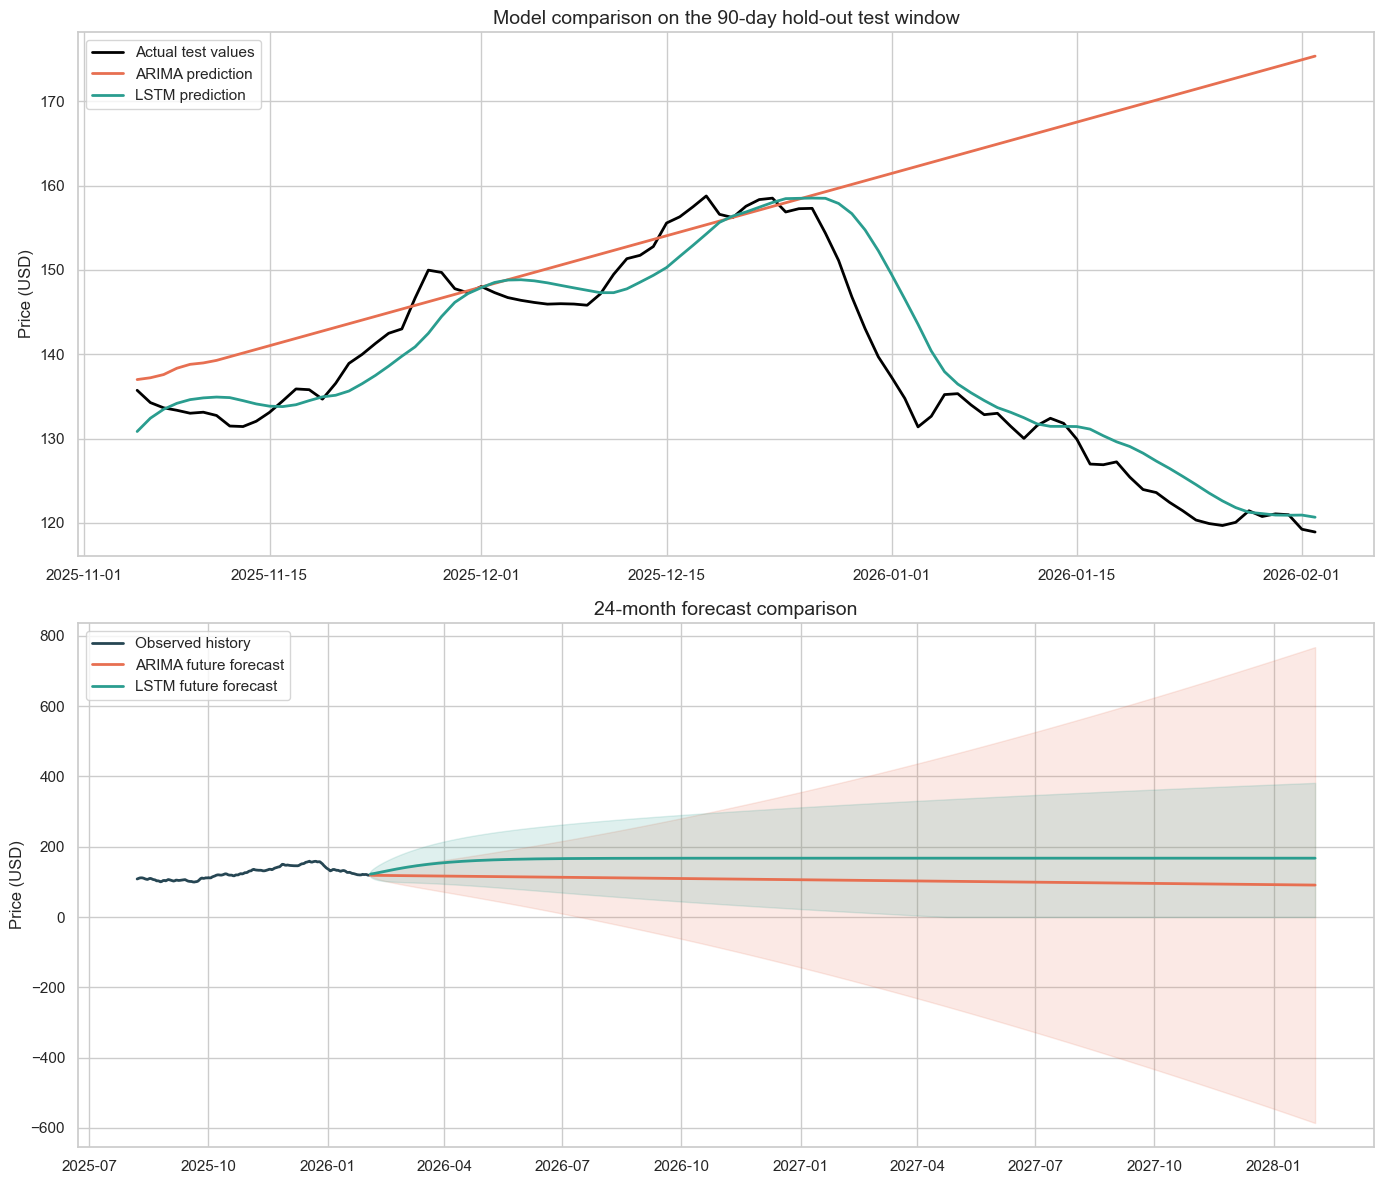

Best hold-out RMSE: LSTM


In [13]:
final_metrics = pd.concat([arima_metrics, lstm_metrics], ignore_index=True).round(4)
display(final_metrics.sort_values("RMSE"))

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

axes[0].plot(test.index, test.values, label="Actual test values", color="#000000", linewidth=2)
axes[0].plot(test.index, arima_test_mean.values, label="ARIMA prediction", color="#e76f51", linewidth=2)
axes[0].plot(test.index, lstm_test_preds, label="LSTM prediction", color="#2a9d8f", linewidth=2)
axes[0].set_title("Model comparison on the 90-day hold-out test window")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

recent_history = series.iloc[-180:]
axes[1].plot(recent_history.index, recent_history.values, label="Observed history", color="#264653", linewidth=2)
axes[1].plot(arima_future_mean.index, arima_future_mean.values, label="ARIMA future forecast", color="#e76f51", linewidth=2)
axes[1].plot(future_index, lstm_future_mean, label="LSTM future forecast", color="#2a9d8f", linewidth=2)
axes[1].fill_between(arima_future_ci.index, arima_future_ci["lower"], arima_future_ci["upper"], color="#e76f51", alpha=0.15)
axes[1].fill_between(future_index, lstm_future_lower, lstm_future_upper, color="#2a9d8f", alpha=0.15)
axes[1].set_title("24-month forecast comparison")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()

plt.tight_layout()
plt.show()

better_model = final_metrics.sort_values("RMSE").iloc[0]["model"]
print(f"Best hold-out RMSE: {better_model}")